In [ ]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv


In [ ]:
import os
os.listdir()

['.config', 'historical_data.csv', 'fear_greed_index.csv', 'sample_data']

In [ ]:
import pandas as pd

trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [ ]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [ ]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
print("Duplicate trades:", trades.duplicated().sum())

Duplicate trades: 0


In [ ]:
trades.info()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
import pandas as pd

# Load data
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

# Convert date
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

# Merge
df = trades.merge(sentiment, on='date', how='left')

# OUTPUT CHECK
print(df.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [ ]:
df['Closed PnL'].describe()

,Closed PnL
count,211224.000000
mean,48.749001
std,919.164828
min,-117990.104100
25%,0.000000
50%,0.000000
75%,5.792797
max,135329.090100


In [ ]:
df['win'] = df['Closed PnL'] > 0

In [ ]:
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.292777
Extreme Greed,0.553282
Fear,0.381787
Greed,0.435707
Neutral,0.494920


In [ ]:
df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,1.891632
Extreme Greed,205.816345
Fear,128.287950
Greed,53.988003
Neutral,27.088803


In [ ]:
df['classification'].value_counts()

,count
classification,
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


In [ ]:
pd.crosstab(df['classification'], df['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898


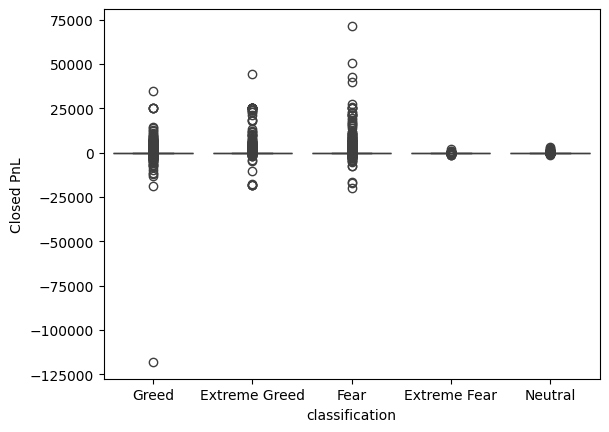

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.show()

In [ ]:
df['leverage'] = df['Size USD'] / 1000

In [ ]:
df['lev_group'] = df['leverage'].apply(lambda x: 'High' if x > 5 else 'Low')

In [ ]:
df['lev_group'].value_counts()

,count
lev_group,
Low,180632
High,30592


In [ ]:
df['lev_group'] = df['leverage'].apply(lambda x: 'High' if x > 5 else 'Low')
df['lev_group'].value_counts()

,count
lev_group,
Low,180632
High,30592


In [ ]:
trade_counts = df['Account'].value_counts()

# Top traders = frequent
top_traders = trade_counts[trade_counts > trade_counts.median()].index

df['freq_group'] = df['Account'].apply(lambda x: 'Frequent' if x in top_traders else 'Infrequent')

In [ ]:
total_pnl = df.groupby('Account')['Closed PnL'].sum()

winners = total_pnl[total_pnl > 0].index

df['pnl_group'] = df['Account'].apply(lambda x: 'Winner' if x in winners else 'Loser')

In [ ]:
df.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,1.891632
Extreme Greed,205.816345
Fear,128.287950
Greed,53.988003
Neutral,27.088803


In [ ]:
df.groupby('classification')['win'].mean()

,win
classification,
Extreme Fear,0.292777
Extreme Greed,0.553282
Fear,0.381787
Greed,0.435707
Neutral,0.494920


In [ ]:
df.groupby('classification')['lev_group'].value_counts(normalize=True)

classification  lev_group
Extreme Fear    Low          0.842218
                High         0.157782
Extreme Greed   Low          0.865682
                High         0.134318
Fear            Low          0.843680
                High         0.156320
Greed           Low          0.837407
                High         0.162593
Neutral         Low          0.858491
                High         0.141509
Name: proportion, dtype: float64

In [ ]:
pd.crosstab(df['classification'], df['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898


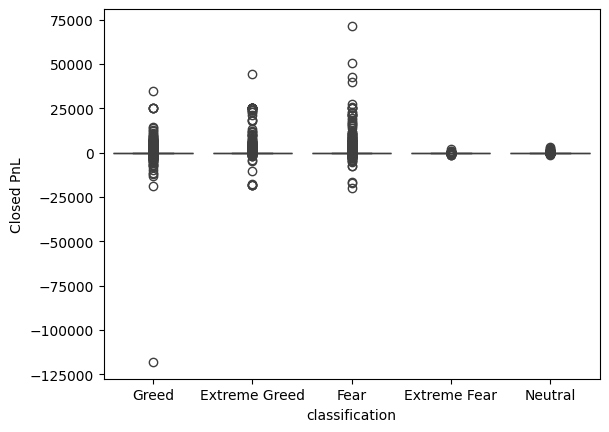

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.show()